In [75]:
import numpy as np;
import pandas as pd
import matplotlib.pyplot as plt;
from scipy.linalg import expm
from scipy.signal import find_peaks

In [3]:
# make S matrix from Hamiltonian
def Smatrix(a,mu,t):
    H = np.array([[a+mu,-a/2,-a/2,0],
                  [-a/2,a,0,-a/2],
                  [-a/2,0,a,-a/2],
                  [0,-a/2,-a/2,a+mu]])
    U = expm(-1j*H*t)
    return U

In [4]:
# make stabiliser states
# ONLY NEED THE TENSOR PRODUCT ONES DUH, ie non entangled

ss = np.array([
# 36 product stabilizer states
# Z ⊗ Z
[1,0,0,0],
[0,1,0,0],
[0,0,1,0],
[0,0,0,1],
# Z ⊗ X
[1/np.sqrt(2),  1/np.sqrt(2), 0, 0],
[1/np.sqrt(2), -1/np.sqrt(2), 0, 0],
[0,0, 1/np.sqrt(2),  1/np.sqrt(2)],
[0,0, 1/np.sqrt(2), -1/np.sqrt(2)],
# Z ⊗ Y
[1/np.sqrt(2),  1j/np.sqrt(2), 0, 0],
[1/np.sqrt(2), -1j/np.sqrt(2), 0, 0],
[0,0, 1/np.sqrt(2),  1j/np.sqrt(2)],
[0,0, 1/np.sqrt(2), -1j/np.sqrt(2)],
# X ⊗ Z
[1/np.sqrt(2),0, 1/np.sqrt(2),0],
[1/np.sqrt(2),0,-1/np.sqrt(2),0],
[0,1/np.sqrt(2),0, 1/np.sqrt(2)],
[0,1/np.sqrt(2),0,-1/np.sqrt(2)],
# X ⊗ X
[1/2, 1/2, 1/2, 1/2],
[1/2,-1/2, 1/2,-1/2],
[1/2, 1/2,-1/2,-1/2],
[1/2,-1/2,-1/2, 1/2],
# X ⊗ Y
[1/2,  1j/2,  1/2,  1j/2],
[1/2, -1j/2,  1/2, -1j/2],
[1/2,  1j/2, -1/2, -1j/2],
[1/2, -1j/2, -1/2,  1j/2],
# Y ⊗ Z
[1/np.sqrt(2),0, 1j/np.sqrt(2),0],
[1/np.sqrt(2),0,-1j/np.sqrt(2),0],
[0,1/np.sqrt(2),0, 1j/np.sqrt(2)],
[0,1/np.sqrt(2),0,-1j/np.sqrt(2)],
# Y ⊗ X
[1/2, 1/2,  1j/2,  1j/2],
[1/2,-1/2,  1j/2, -1j/2],
[1/2, 1/2, -1j/2, -1j/2],
[1/2,-1/2, -1j/2,  1j/2],
# Y ⊗ Y
[1/2,  1j/2,  1j/2, -1/2],
[1/2, -1j/2,  1j/2,  1/2],
[1/2,  1j/2, -1j/2,  1/2],
[1/2, -1j/2, -1j/2, -1/2],

# 24 entangled stabilizer states
# Bell basis (real)
[1/np.sqrt(2),0,0, 1/np.sqrt(2)],
[1/np.sqrt(2),0,0,-1/np.sqrt(2)],
[0,1/np.sqrt(2), 1/np.sqrt(2),0],
[0,1/np.sqrt(2),-1/np.sqrt(2),0],
# Bell with i phases
[1/np.sqrt(2),0,0, 1j/np.sqrt(2)],
[1/np.sqrt(2),0,0,-1j/np.sqrt(2)],
[0,1/np.sqrt(2), 1j/np.sqrt(2),0],
[0,1/np.sqrt(2),-1j/np.sqrt(2),0],
# XX-type entangled
[1/2, 1/2, 1/2,-1/2],
[1/2,-1/2, 1/2, 1/2],
[1/2, 1/2,-1/2, 1/2],
[1/2,-1/2,-1/2,-1/2],
# YY-type entangled
[1/2,  1j/2, -1j/2,  1/2],
[1/2, -1j/2, -1j/2, -1/2],
[1/2,  1j/2,  1j/2, -1/2],
[1/2, -1j/2,  1j/2,  1/2],
# mixed phase family 1
[1/2, 1/2,  1j/2, -1j/2],
[1/2,-1/2,  1j/2,  1j/2],
[1/2, 1/2, -1j/2,  1j/2],
[1/2,-1/2, -1j/2, -1j/2],
# mixed phase family 2
[1/2,  1j/2,  1/2, -1j/2],
[1/2, -1j/2,  1/2,  1j/2],
[1/2,  1j/2, -1/2,  1j/2],
[1/2, -1j/2, -1/2, -1j/2],
], dtype=complex)

In [5]:
print(ss.shape)
print(len(ss))
ss[0,:]

(60, 4)
60


array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])

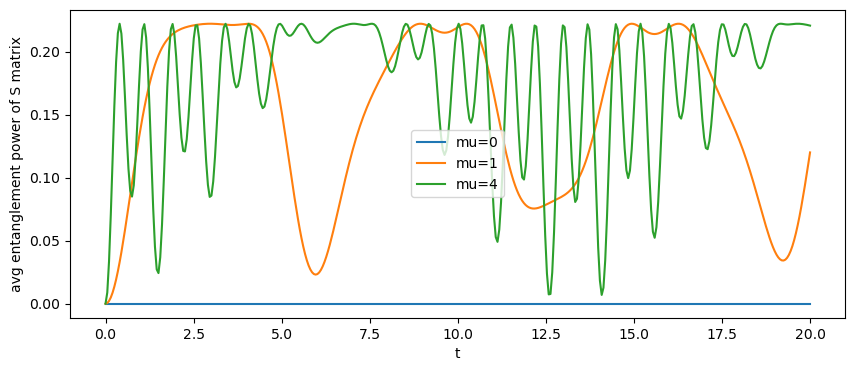

In [39]:
# variables for state evolution, a is energy state splitting, mu is interaction strength, t is time
a=1
# mu=1
# t=1
mu_list=np.array([0,1,4])
t_list=np.linspace(0,20,400)

plt.figure(figsize=(10,4))

for k, mu in enumerate(mu_list) :
    entanglement_list = []
    for n, t in enumerate(t_list) :
        # get each stabiliser state, evolve it, make density matrix for both particles, 
        # trace over particle b, square reduced density matrix and trace again to get purity
        purity_list = []
    
        for i in range(36): # because we want the intially nonentangled states
            psiin = ss[i,:] # ith state
            psiout = Smatrix(a,mu,t) @ psiin
            
            rhoab = np.outer(psiout, psiout.conj())
            # print('rhoab: ',rhoab)
            rhoab = rhoab.reshape(2,2,2,2)
            rhoa = np.trace(rhoab,axis1=1,axis2=3) # reduced density matrix for a, traces over second (index1) and 4th index which is b
            
            purity = np.trace(rhoa @ rhoa)
            chopped_purity = complex(purity.real, 0 if abs(purity.imag) < 1e-10 else purity.imag) # removes tiny imaginary components which make the calculations hard
            # print('purity=',purity)
            if purity.real<0:
                print('neg purity for state i=',i)

            purity_list.append(chopped_purity)
        # entanglement power is average entanglement of all stabiliser states
        entanglement = 1-abs(sum(purity_list))/36 # this is avg entanglement power for a particular time and particular mu
        # print('entanglement power =',entanglement)
        entanglement_list.append(entanglement)
    
    plt.plot(t_list,entanglement_list,label=f"mu={mu}")
plt.legend()
plt.xlabel('t')
plt.ylabel('avg entanglement power of S matrix')
plt.show()

In [31]:
def Epower(mu_list,t_list,psiin):
    plt.figure(figsize=(10,4))
    entanglement_list_mu=[]
    for k, mu in enumerate(mu_list) :
        entanglement_list = []
        for n, t in enumerate(t_list) :
            # get initial state, evolve it, make density matrix for both particles, 
            # trace over particle b, square reduced density matrix and trace again to get purity
            psiout = Smatrix(a,mu,t) @ psiin
            rhoab = np.outer(psiout, psiout.conj())
            rhoab = rhoab.reshape(2,2,2,2)
            rhoa = np.trace(rhoab,axis1=1,axis2=3) # reduced density matrix for a, traces over second (index1) and 4th index which is b
            
            purity = np.trace(rhoa @ rhoa)
            chopped_purity = complex(purity.real, 0 if abs(purity.imag) < 1e-10 else purity.imag) # removes tiny imaginary components which make the calculations hard
            # print('purity=',purity)
            if purity.real<0:
                print('neg purity for state i=',i)
            entanglement = 1-chopped_purity 
            entanglement_list.append(entanglement)
            
        plt.plot(t_list,entanglement_list,label=f"mu={mu}")
        entanglement_list_mu.append(entanglement_list)
    plt.legend()
    plt.xlabel('t')
    plt.ylabel(f'entanglement power')
    plt.title(rf'$\psi_{{in}}=$[{psiin[0]:.3g}, {psiin[1]:.3g}, {psiin[2]:.3g}, {psiin[3]:.3g}]')
    plt.ylim(0,0.6)
    plt.show()
    return entanglement_list_mu

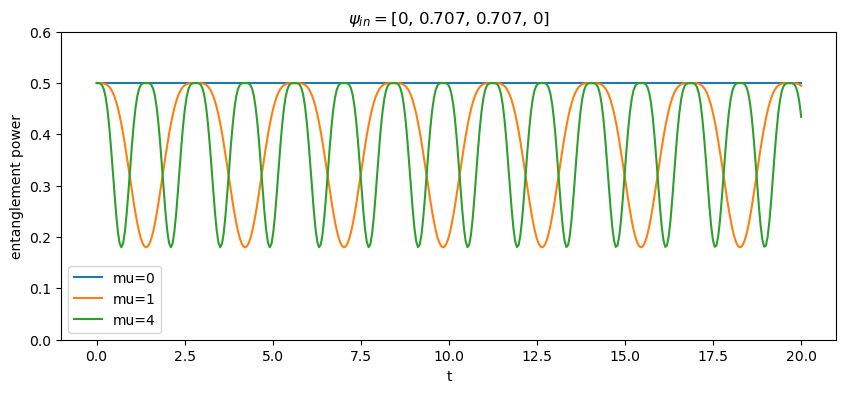

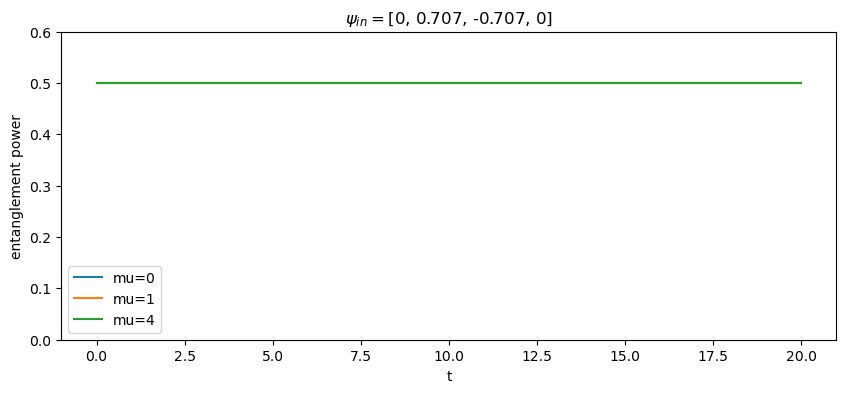

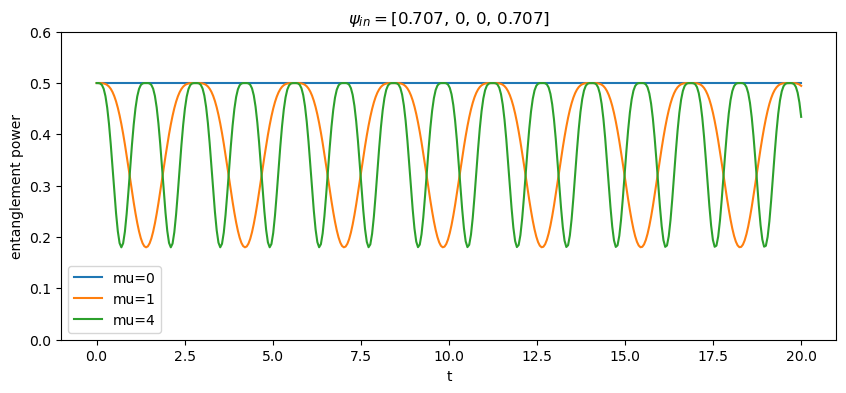

In [32]:
mu_list=np.array([0,1,4])
t_list=np.linspace(0,20,400)
psiin=np.array([0,1/np.sqrt(2),1/np.sqrt(2),0]) # basis LL LR RL RR
entanglement_list_mu=Epower(mu_list,t_list,psiin)

psiin=np.array([0,1/np.sqrt(2),-1/np.sqrt(2),0]) # basis LL LR RL RR
entanglement_list_mu=Epower(mu_list,t_list,psiin)

psiin=np.array([1/np.sqrt(2),0,0,1/np.sqrt(2)]) # basis LL LR RL RR
entanglement_list_mu=Epower(mu_list,t_list,psiin)

MAGIC POWER

In [53]:
def M2(psiout):
    traces=[]
    I=np.array([[1,0],[0,1]])
    X=np.array([[0,1],[1,0]])
    Y=np.array([[0,-1j],[1j,0]])
    Z=np.array([[1,0],[0,-1]])
    pauli=np.array([I,X,Y,Z])
    # print(pauli.shape)
    # print(pauli[3])
    
    rho=np.outer(psiout,psiout.conj())
    
    for i in range(4):
        for j in range(4):
            # print('i',i,' j',j)
            P=np.kron(pauli[i],pauli[j])
            # print('P shape',P.shape)
            trace=np.trace(rho@P)**4
            traces.append(trace)
    xi2=1/4*np.sum(traces)
    M2=-np.log(xi2)
    chopped_M2=complex(M2.real, 0 if abs(M2.imag) < 1e-10 else M2.imag) # removes tiny imaginary components which make the calculations hard
    return chopped_M2

max magic for mu=1 = (0.6558223979245115+0j)
max magic for mu=4 = (0.6186635509710652+0j)


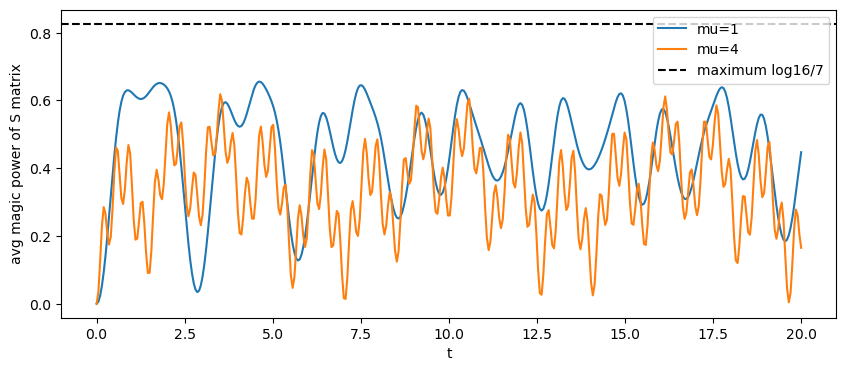

In [57]:
# variables for state evolution, a is energy state splitting, mu is interaction strength, t is time
a=1
mu_list=np.array([1,4])
t_list=np.linspace(0,20,400)

plt.figure(figsize=(10,4))

for k, mu in enumerate(mu_list) :
    magicpower_list = []
    for n, t in enumerate(t_list) :
        # get each stabiliser state, evolve it
        magic_list=[]
        for i in range(60): # because we want the intially non-magic states, so all the stabiliser states
            psiin = ss[i,:] # ith state
            psiout = Smatrix(a,mu,t)@psiin
            magic_list.append(M2(psiout))
        
        # magic power is average magic induced in all stabiliser states
        magicpower = sum(np.array(magic_list))/60 # this is avg magic power for a particular time and particular mu
        magicpower_list.append(magicpower)
    
    plt.plot(t_list,magicpower_list,label=f"mu={mu}")
    print(f'max magic for mu={mu} = {np.max(magicpower_list)}')
plt.axhline(y=np.log(16/7),c='k',ls='--',label='maximum log16/7') # maximal possible magic for two-qubit state, from Liu2026
# plt.axhline(y=np.log(16/7)/2,c='grey',ls='--',label='half maximum')
plt.legend()
plt.xlabel('t')
plt.ylabel('avg magic power of S matrix')
plt.show()

In [ ]:
# CAUTION, WILL JUST PLOT THE LAST THING STORED! 
plt.figure(figsize=(10,4))
plt.plot(t_list,magicpower_list,label='magic')
plt.plot(t_list,entanglement_list,label='entangle')
plt.legend()
plt.title('avg Entangle vs Magic power for mu=4')
plt.xlabel('t')
plt.show()
# hello 

In [55]:
def Mpower(mu_list,t_list,psiin):
    plt.figure(figsize=(10,4))
    magic_list_mu=[]
    for k, mu in enumerate(mu_list) :
        magic_list = []
        for n, t in enumerate(t_list) :
            # get each stabiliser state, evolve it
            psiout = Smatrix(a,mu,t)@psiin
            magic=M2(psiout)
            
            # magic power is average magic induced in all stabiliser states
            magic_list.append(magic)
        
        plt.plot(t_list,magic_list,label=f"mu={mu}")
        magic_list_mu.append(magic_list)
    plt.axhline(y=np.log(16/7),c='k',ls='--',label='maximum log16/7') # maximal possible magic for two-qubit state, from Liu2026
    # plt.axhline(y=np.log(16/7)/2,c='grey',ls='--',label='half maximum')
    plt.legend()
    plt.xlabel('t')
    plt.ylabel(f'magic power')
    plt.title(rf'$\psi_{{in}}=$[{psiin[0]:.3g}, {psiin[1]:.3g}, {psiin[2]:.3g}, {psiin[3]:.3g}]')
    plt.ylim(-0.1,0.9)
    plt.show()
    return np.array(magic_list_mu)

In [85]:
#fourier analysis
def fourier(t_list,signal):
    dt=t_list[1]-t_list[0]
    fft_magic=np.fft.fft(signal) # could add dtype float to np array so that ensured real numbers
    freq=np.fft.fftfreq(len(signal),d=dt)
    
    #only positive frequencies
    mask=freq>0
    freq=freq[mask]
    fft_magic=fft_magic[mask]
    power=np.abs(fft_magic)**2
    
    plt.plot(freq,power,'k')
    plt.xlabel('freq')
    plt.ylabel('power of magic fft')
    # plt.yscale('log')
    
    #find peaks
    peaks, _ = find_peaks(power,height=0.1)
    # print(peaks.shape)
    for i in range(len(peaks)):
        plt.axvline(x=freq[peaks[i]],ls='--',label=f'f={freq[peaks[i]]:.3g}')
    plt.legend()
    plt.show()
    return freq[peaks],power[peaks]

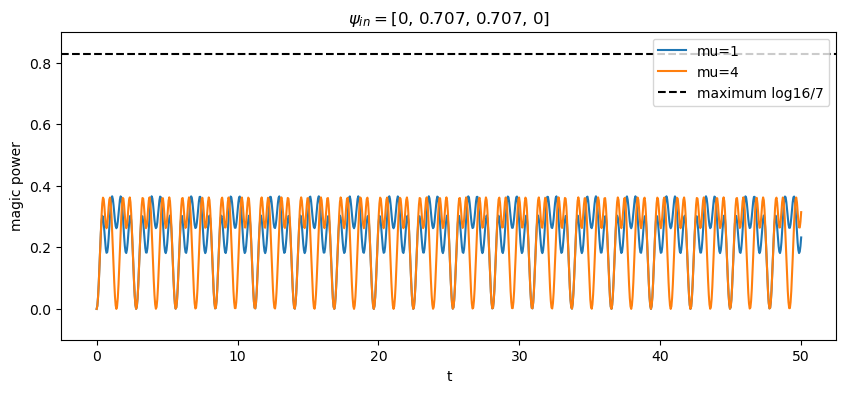

max magic = (0.3623130811810396+0j) for mu=4


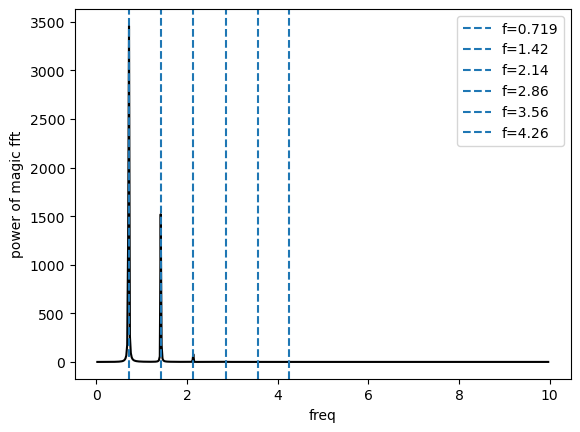

[0.71928 1.41858 2.13786 2.85714 3.55644 4.25574] [3.45733719e+03 1.52010478e+03 8.01829970e+01 3.31727507e+00
 1.61322944e-01 1.06103780e-01]


In [87]:
a=1
mu_list=np.array([1,4])
t_list=np.linspace(0,50,1000)

psiin=np.array([0,1/np.sqrt(2),1/np.sqrt(2),0]) # basis LL LR RL RR
magic_list_mu=Mpower(mu_list,t_list,psiin)
print(f'max magic = {np.max(magic_list_mu[1,:])} for mu={mu_list[1]}')

signal=magic_list_mu[1,:]
(freqs,peaks)=fourier(t_list,signal)
# print(freqs,peaks)

In [ ]:
psiin=np.array([1,0,0,0]) # basis LL LR RL RR
magic_list_mu=Mpower(mu_list,t_list,psiin)
# print(magic_list_mu[1,:].shape)
print(f'max magic = {np.max(magic_list_mu[0,:])} for mu={mu_list[0]}')
print(f'max magic = {np.max(magic_list_mu[1,:])} for mu={mu_list[1]}')

psiin=np.array([0,1/np.sqrt(2),-1/np.sqrt(2),0]) # basis LL LR RL RR
magic_list_mu=Mpower(mu_list,t_list,psiin)
print(f'max magic = {np.max(magic_list_mu[1,:])} for mu={mu_list[1]}')